# 10. Radiative Transfer (RT)

RAMSES can run with **radiative transfer** (`RT=1`): on top of the gas it transports, per
photon group `g`, a photon number density `Np`g` and the photon flux `Fx`g`/`Fy`g`/`Fz`g`
(an **M1 moment** field, so `nvarrt = 4·nGroups`). Mera reads it with **`getrt`**, exactly
like `gethydro`.

**The whole tutorial is one pipeline:** `getinfo → getrt / gethydro → getvar → projection`.
Two objects, one bridge:
- the **photon field** lives in the RT object (`getrt`),
- the **ionization state it produces** (xHII, …) lives in the **hydro** object (`gethydro`),
- Mera connects them through the RT descriptor index `iIons`.

We build it up simplest-first: one striking map in three calls, then RT photon fields, then
the hydro to RT bridge, then physical units, then a reference card.

## The physics we expect to see

The example is the **RAMSES Strömgren-sphere test** (`stromgren.nml`, here `ramses-2025.05`):
a point source at the box **corner** ionizing a *uniform* neutral hydrogen medium
(`X=1`, `n_H≈10⁻³ cm⁻³`, box 15 kpc, 3 photon groups).

A source emitting `Ṅγ` ionizing photons/s into gas of density `n_H` builds an ionized sphere
whose photo-ionizations balance recombinations, the **Strömgren sphere** of radius

$$R_S = \left(\frac{3\,\dot N_\gamma}{4\pi\,\alpha_B\,n_H^2}\right)^{1/3},$$

bounded by a thin **ionization front** where `xHII` drops from ≈1 to ≈0. Because the medium
is uniform and near photoionization equilibrium, both `xHII` and temperature are essentially
single-valued functions of radius. The maps and profiles below recover exactly this picture
(and we check `R_S` quantitatively at the end).

## Hello RT, three calls and a map

The simplest end-to-end example: load the snapshot, load the RT data, project one field.
`projection` flattens the 3D field onto a 2D map (here the volume-weighted average along z;
the modes are defined once below). `:Np_total` is the sum over all groups, it needs no group
or descriptor knowledge, so it is the perfect first look.


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0 | Julia 1.12.7 | 4 threads

[Mera]: 2026-08-31T13:57:52.461



Code: RAMSES
output [3] summary:
mtime: 2026-08-20T16:57:42.963


ctime: 2026-08-20T16:57:42.963
simulation time: 30.01 [Myr]
boxlen: 15.0 [kpc]
ncpu: 8
ndim: 3
cosmological:  false
-------------------------------------------------------
amr:           true
level of uniform grid: 5 --> cellsize(s): 468.75 [pc]
-------------------------------------------------------
hydro:         true
hydro-variables:  

8  --> (:rho, :vx, :vy, :vz, :p, :scalar_00, :scalar_01, :scalar_02)
hydro-descriptor: (:density, :velocity_x, :velocity_y, :velocity_z, :pressure, :scalar_00, :scalar_01, :scalar_02)
γ: 1.4
gravity:       false
particles:     false
-------------------------------------------------------
rt:            true
rt-variables: 12
nIons: 3
nGroups: 3
iIons: 6
photon group energies [eV]: 

[18.85, 35.08, 65.67]
-------------------------------------------------------
clumps:           false
-------------------------------------------------------
namelist-file: ("&COOLING_PARAMS", "&AMR_PARAMS", "&OUTPUT_PARAMS", "&BOUNDARY_PARAMS", "&RT_PARAMS", "&RT_GROUPS\t\t\t! Blackbody at T=1d5 Kelvin", "&UNITS_PARAMS", "&RUN_PARAMS", "! the Sedov fixture the boundaries here are NOT periodic (see &BOUNDARY_PARAMS), so plain", "&HYDRO_PARAMS", "! Run:  mpirun -np 8 <build>/bin/ramses3d_rt stromgren3d.nml > run.log 2>&1", "&INIT_PARAMS", "&REFINE_PARAMS")
-------------------------------------------------------
timer-file:       true
compilation-file: true
makefile:         true
patchfile:        true



Processing files:   0%|                                                  |  ETA: N/A (  N/A  s/it)

Processing files: 100%|██████████████████████████████████████████████████| Time: 0:00:00 (66.58 ms/it)



✓ File processing complete! Combining results...


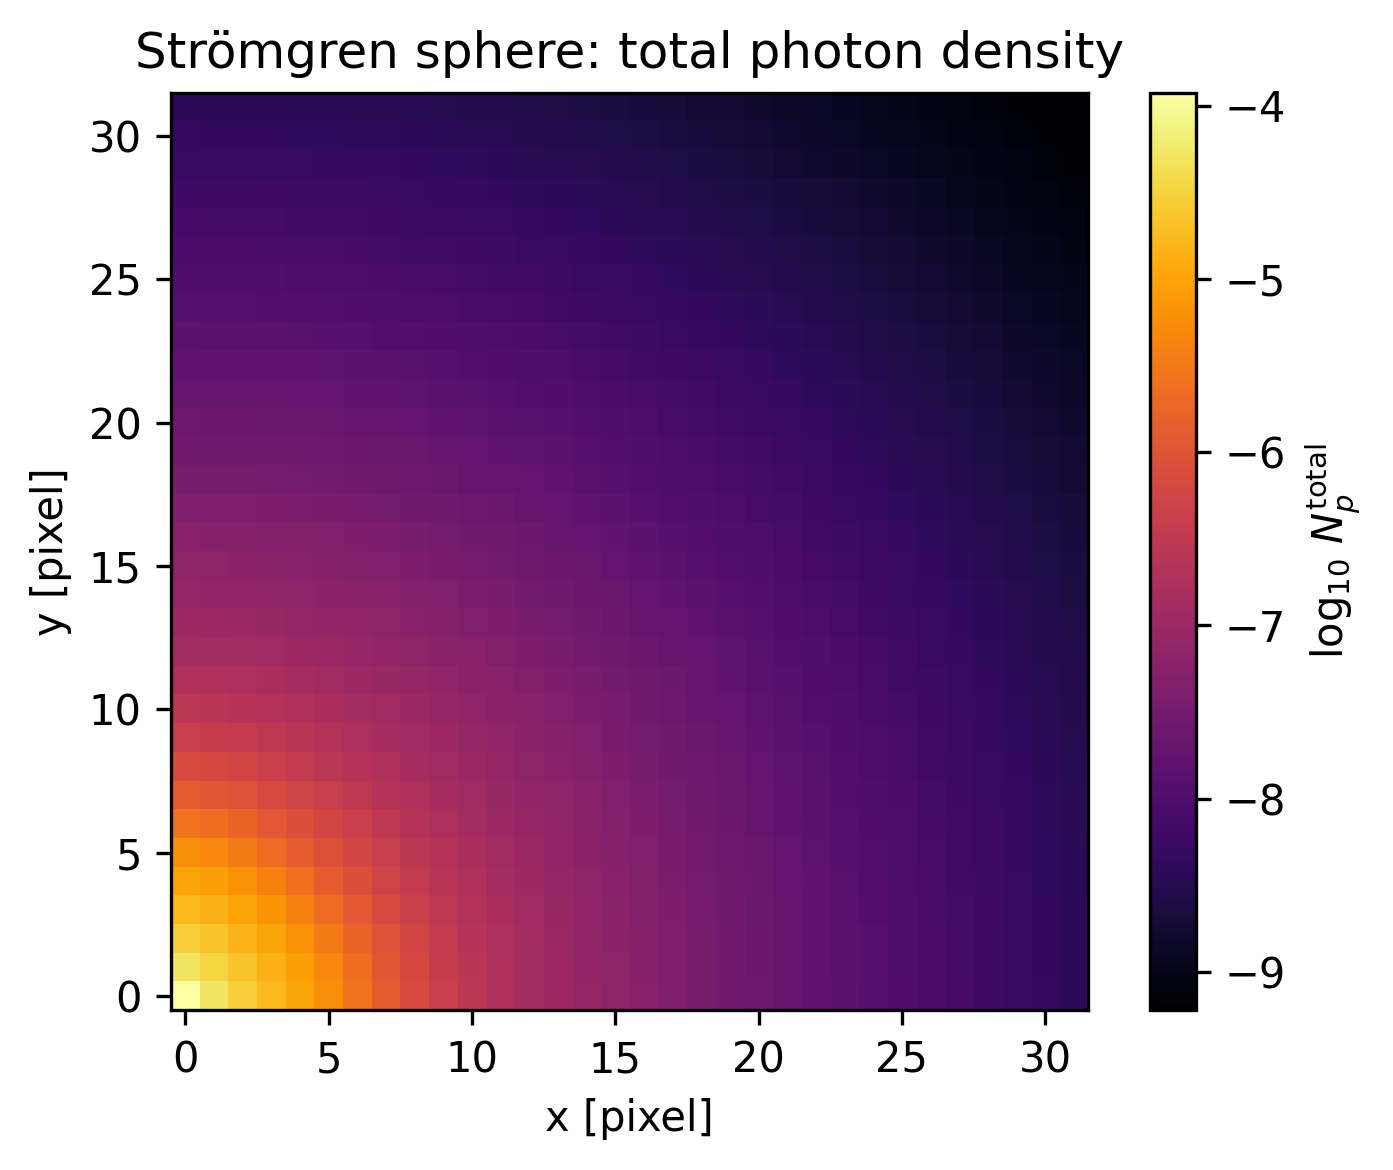

In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera, PyPlot, Statistics
rc("figure", dpi=300); rc("savefig", dpi=300)

"Show a 2D Mera map (transpose to x–y; optional log10 with non-positive values blanked)."
function show_map(M; logscale=false, cmap="inferno", clabel="", ttl="")
    A = permutedims(M)
    logscale && (A = map(x -> x > 0 ? log10(x) : NaN, A))
    figure(figsize=(5,4)); imshow(A, origin="lower", cmap=cmap)
    colorbar(label=clabel); title(ttl)
    xlabel("x [pixel]"); ylabel("y [pixel]"); tight_layout()
end

path = "$MERA_EXAMPLES/RAMSES-PUBLIC/stromgren3d"   # published test simulation, see its README
info = getinfo(3, path)                 # prints the simulation overview incl. the RT block
rt   = getrt(info, verbose=false)       # → RtDataType, like gethydro
p    = projection(rt, :Np_total, verbose=false, show_progress=false)
show_map(p.maps[:Np_total]; logscale=true,
         clabel=L"$\log_{10}\,N_p^{\rm total}$", ttl="Strömgren sphere: total photon density")

**Takeaway:** `getinfo → getrt → projection → show_map` already reveals the ionized sphere.
Everything below varies *what* we put through this same pipeline.

## What is in the RT object?

`getinfo` reported the RT block; programmatically the available photon fields are listed in
`info.rt_variable_list`, and the leaf-cell table is `rt.data` (use `viewfields(rt)` to browse
the object's fields).

In [2]:
println("RT run? ", info.rt, "    nvarrt = ", info.nvarrt, "  (= 4 × nGroups)")
info.rt_variable_list      # the per-group symbols Mera exposes: :Np1, :Fx1, :Fy1, :Fz1, …

RT run? true    nvarrt = 12  (= 4 × nGroups)


12-element Vector{Symbol}:
 :Np1
 :Fx1
 :Fy1
 :Fz1
 :Np2
 :Fx2
 :Fy2
 :Fz2
 :Np3
 :Fx3
 :Fy3
 :Fz3

## Variables with `getvar`, the simplest form

`getvar(object, :symbol)` returns one array (per leaf cell). That is the whole idea; later we
pass a *vector* of symbols to get several at once, and a unit symbol to convert.

In [3]:
Np1 = getvar(rt, :Np1)                 # one photon group, code units
(Np1_min = minimum(Np1), Np1_max = maximum(Np1))

(Np1_min = 1.9695717303063266e-49, Np1_max = 0.0010425690408447943)

## A first physics hook: radial fall-off

Binning the total photon density by distance from the (corner) source shows the expected
geometric `~1/r²` dilution, then a steeper drop once absorption sets in near the front. We
define a tiny object-agnostic helper `radial_mean` here and reuse it later on the gas data.
This also introduces the `getvar(obj, :var, :unit)` conversion form (radius in kpc).

[Mera] Hint: getvar(:r_sphere) has no `center`: it is measured about the box CORNER.
             Pass center=:bc, or center=[x, y, z] with center_unit. This is a separate
             argument from the `center` that places a region; give both the same origin.
             (shown once per session; verbose(false) silences Mera's messages)


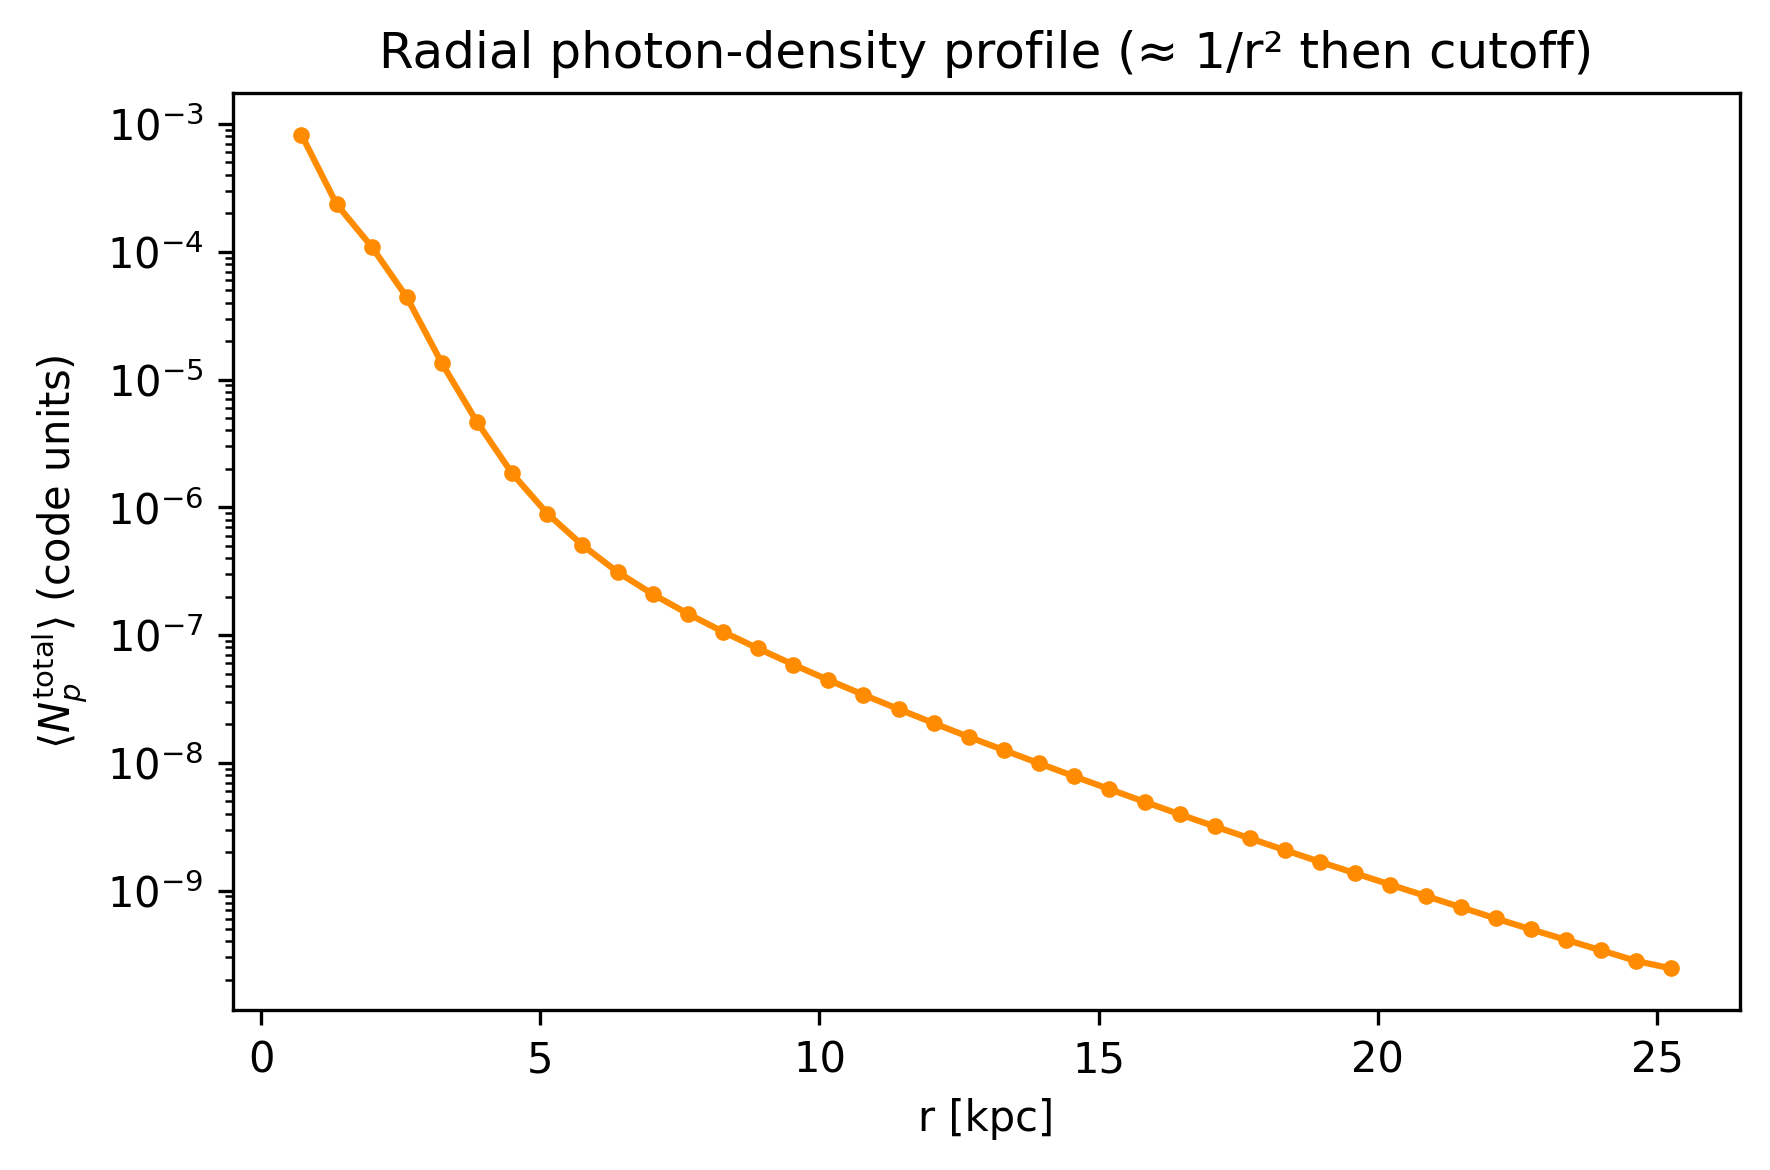

In [4]:
"Radial mean of q(r) in nbins (plain arrays; empty bins → NaN). Reused on rt and gas."
function radial_mean(r, q; nbins=40)
    edges = range(minimum(r), maximum(r), length=nbins+1)
    r_centers = [(edges[i] + edges[i+1]) / 2 for i in 1:nbins]
    means = [ (m = (r .>= edges[i]) .& (r .< edges[i+1]); any(m) ? sum(q[m]) / count(m) : NaN) for i in 1:nbins ]
    return r_centers, means
end

r = getvar(rt, :r_sphere, :kpc, center=[0.0, 0.0, 0.0])     # source at the corner
rprof, npprof = radial_mean(r, getvar(rt, :Np_total))
figure(figsize=(6,4)); semilogy(rprof, npprof, "-o", ms=3, color="darkorange")
xlabel("r [kpc]"); ylabel(L"$\langle N_p^{\rm total}\rangle$ (code units)")
title("Radial photon-density profile (≈ 1/r² then cutoff)"); tight_layout();

## Region selection

`subregion` and `shellregion` work on an `RtDataType` just like on hydro, handy for zooms
and shells. Note the two centre conventions used here: `[:bc]` = **box centre** (7.5 kpc),
while the **source** sits at the corner `[0,0,0]` (used for the radial profiles).

(full_cells = length(rt.data), sphere_cells = length(sub.data), shell_cells = length(shell.data)) = (full_cells = 32768, sphere_cells = 6176, shell_cells = 8864)

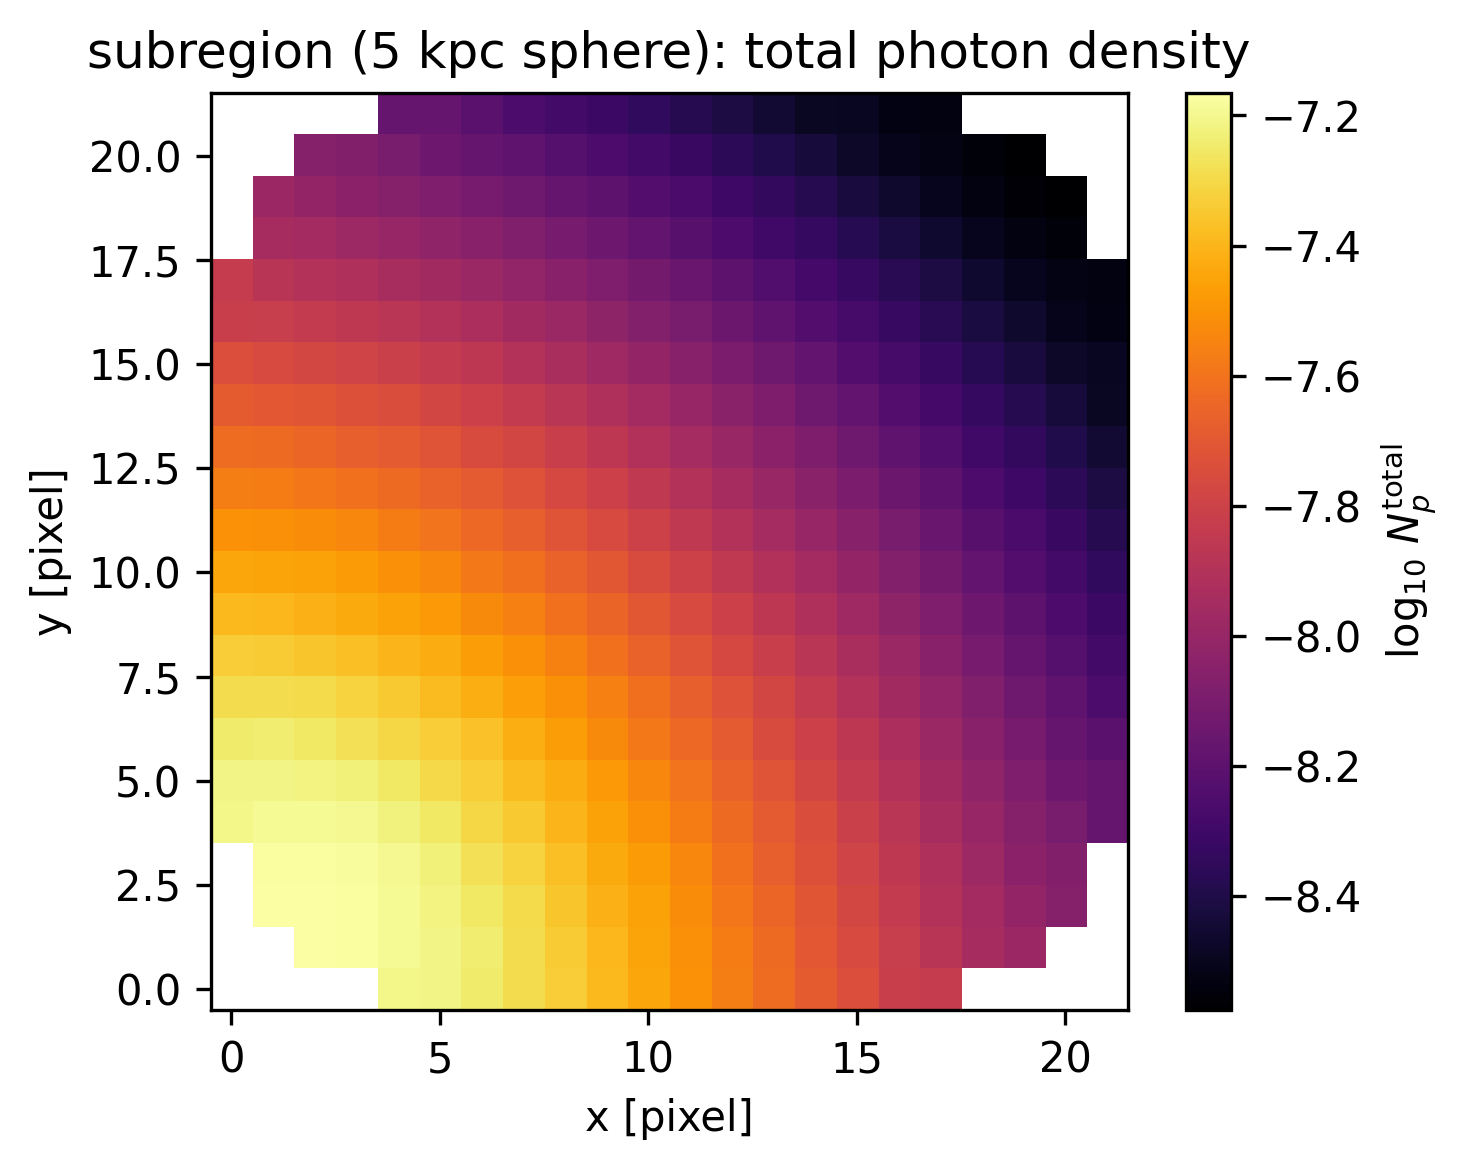

In [5]:
sub   = subregion(rt,  :sphere, radius=5.0,        center=[:bc], range_unit=:kpc, verbose=false)
shell = shellregion(rt, :sphere, radius=[3.0, 6.0], center=[:bc], range_unit=:kpc, verbose=false)
@show (full_cells = length(rt.data), sphere_cells = length(sub.data), shell_cells = length(shell.data))

# payoff: the selection is itself an RtDataType, project the 5 kpc sphere
psub = projection(sub, :Np_total, verbose=false, show_progress=false)
show_map(psub.maps[:Np_total]; logscale=true, clabel=L"$\log_{10}\,N_p^{\rm total}$",
         ttl="subregion (5 kpc sphere): total photon density")

## The projection model (once)

A projection collapses the 3D AMR field onto a 2D pixel grid. Two modes:

| mode | meaning | use |
|---|---|---|
| `:standard` (default) | volume-weighted **average** along the line of sight | maps of intensive fields (xHII, reduced flux) |
| `:sum` | volume-weighted **sum** per pixel, `Σ q·V_cell` | totals (the whole map sums to the box total) |

RT defaults mass-weighting → **volume**-weighting (RT carries no mass). A thin `zrange`
turns a projection into a **slice**. Note: `:sum` carries a cell-**volume** factor, so it is
proportional to a column total, **not** the path-length integral `∫q dz`; RT fields have no
`:sd` (surface-density) analogue.

## Photon flux, the vectorial field (M1)

RT is vectorial: each group carries a flux **F** = (Fx, Fy, Fz). The **reduced flux**

$$f = \frac{|\mathbf F|}{c\,N_p} \in [0,1]$$

measures how *beamed* the radiation is in the M1 closure: `f → 1` is a free-streaming radial
beam, `f → 0` is an isotropic field. Here we also meet the **one-pass multi-variable** form
`projection(rt, [:Np1, :Fx1, :Fy1])`, which returns all three maps in a single call, and
overlay the flux **direction** as arrows on the photon-density map.

maximum(getvar(rt, :reducedflux1)) = 0.9888163855508687
maximum(getvar(rt, :Fmag1)) = 0.0001338306154295702


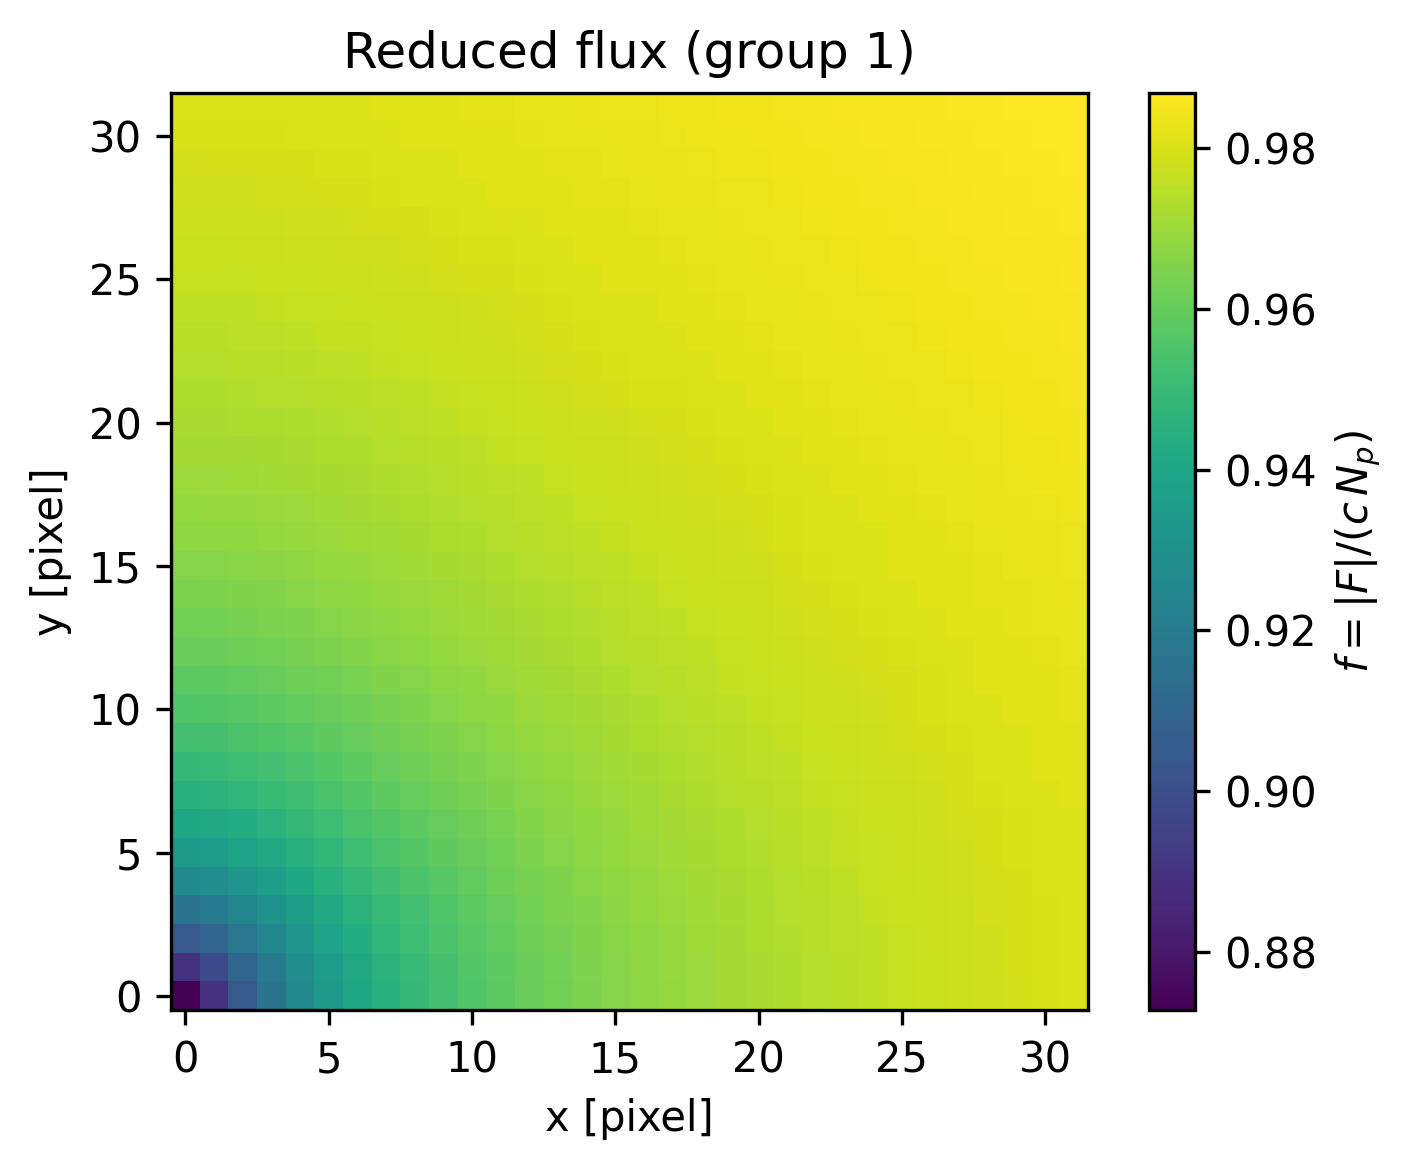

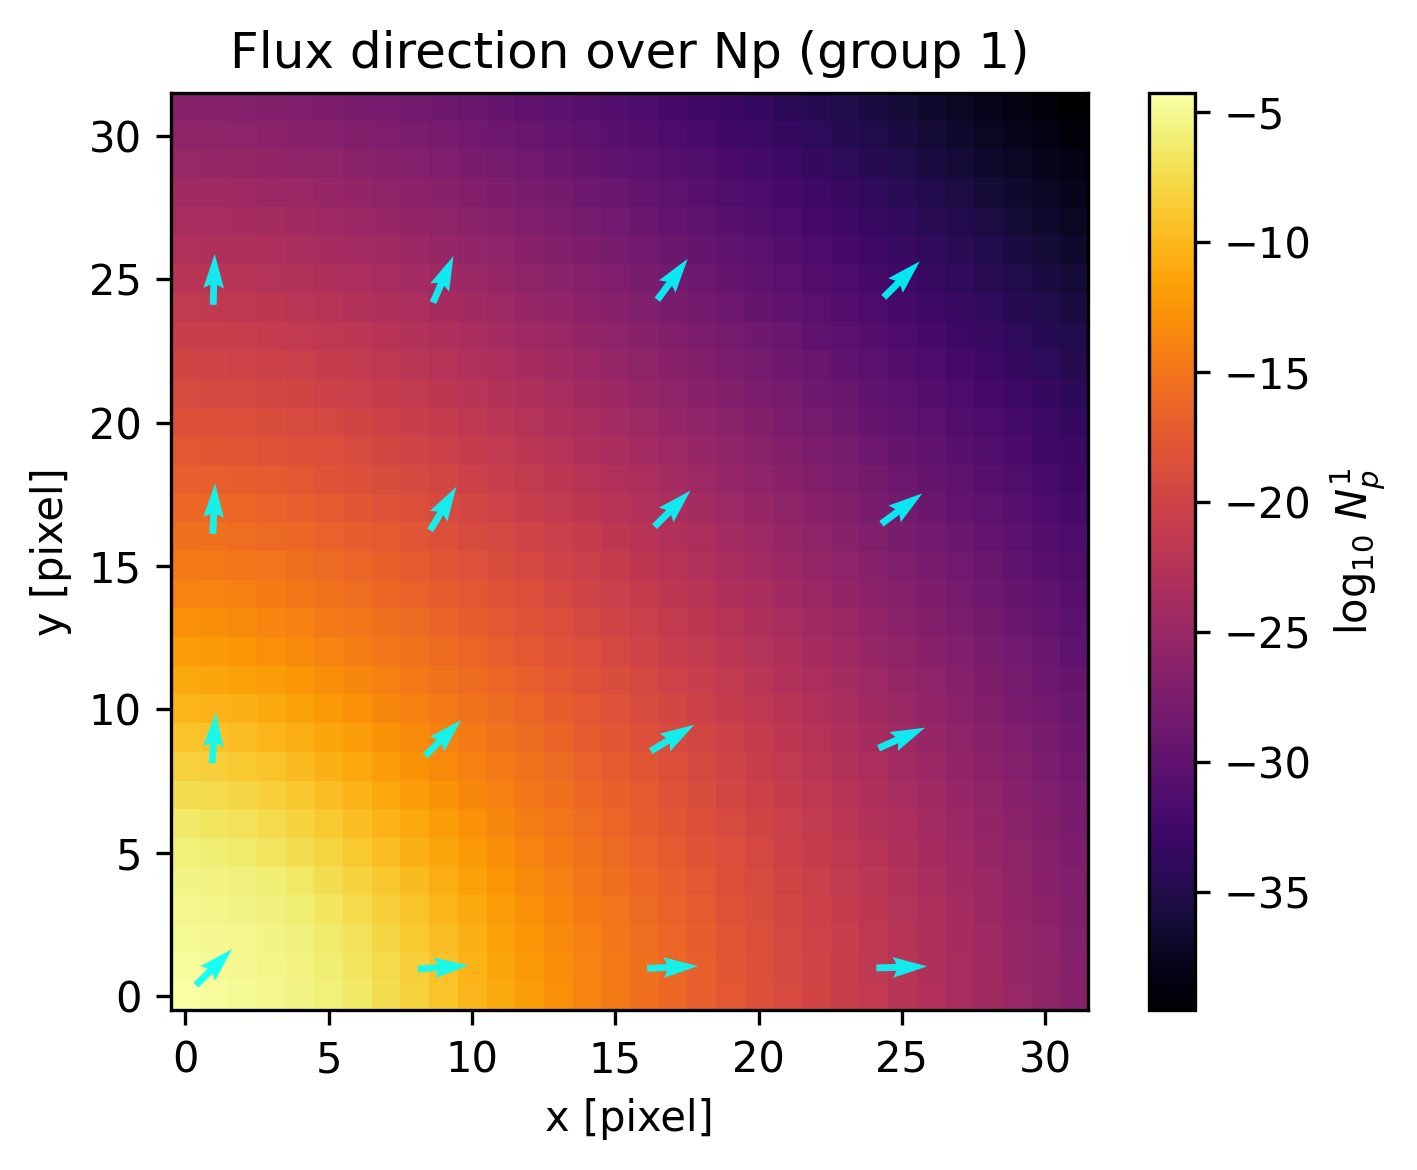

In [6]:
@show maximum(getvar(rt, :reducedflux1))      # bounded to [0,1]; ~0.99 along the rays
@show maximum(getvar(rt, :Fmag1))             # |F| of group 1 (code units)

pf = projection(rt, [:Np1, :Fx1, :Fy1], verbose=false, show_progress=false)   # 3 maps, 1 pass
fx = permutedims(pf.maps[:Fx1]); fy = permutedims(pf.maps[:Fy1])
mag = sqrt.(fx.^2 .+ fy.^2) .+ 1e-50
u = fx ./ mag; v = fy ./ mag                  # unit vectors (direction only)
ny, nx = size(u); s = 8; xs = collect(1:s:nx); ys = collect(1:s:ny)

prf = projection(rt, :reducedflux1, verbose=false, show_progress=false)
show_map(prf.maps[:reducedflux1]; cmap="viridis", clabel=L"$f=|F|/(c\,N_p)$", ttl="Reduced flux (group 1)")

show_map(pf.maps[:Np1]; logscale=true, clabel=L"$\log_{10}\,N_p^{1}$", ttl="Flux direction over Np (group 1)")
quiver(xs, ys, u[ys, xs], v[ys, xs], color="cyan", pivot="mid", alpha=0.9);

## Photon groups & energy bands

Why `Np1`, `Np2`, `Np3`? RAMSES-RT splits the spectrum into `nGroups` **energy bands** set at
the **ionization thresholds** of H and He, so each band ionizes a species:

| group | band [eV] | ionizes (threshold) |
|---|---|---|
| 1 | 13.6, 24.59 | H I → H II (13.6 eV) |
| 2 | 24.59, 54.42 | He I → He II (24.59 eV) |
| 3 | > 54.42 | He II → He III (54.42 eV) |

*These are the generic RAMSES-RT band definitions. This run is **pure hydrogen** (`X=1`, `Y=0`), so
all helium cross-sections are zero, groups 2 and 3 here simply supply **harder hydrogen-ionizing**
photons (smaller H I cross-sections), and only the 13.6 eV H I threshold is physically active.*

The band edges (`groupL0/L1`) and the SED-averaged **mean energy** per band (`group_egy`) live
in `info.descriptor.rt` / `info.descriptor.rtPhotonGroups`. Resolving bands lets the code follow
**spectral hardening**, higher-energy photons have smaller cross-sections `≈ (ν/ν₀)⁻³`, so they
penetrate deeper and raise the field's mean energy outward. The bar chart is the **integrated**
photon budget per band (not a spatial map).

This completes the **RT-native** tour, raw fields, geometry, regions, projection modes, flux
vectors and spectral bands, all through the same `getvar` / `projection` pipeline.

info.descriptor.rt[:group_egy] = [18.85, 35.08, 65.67]


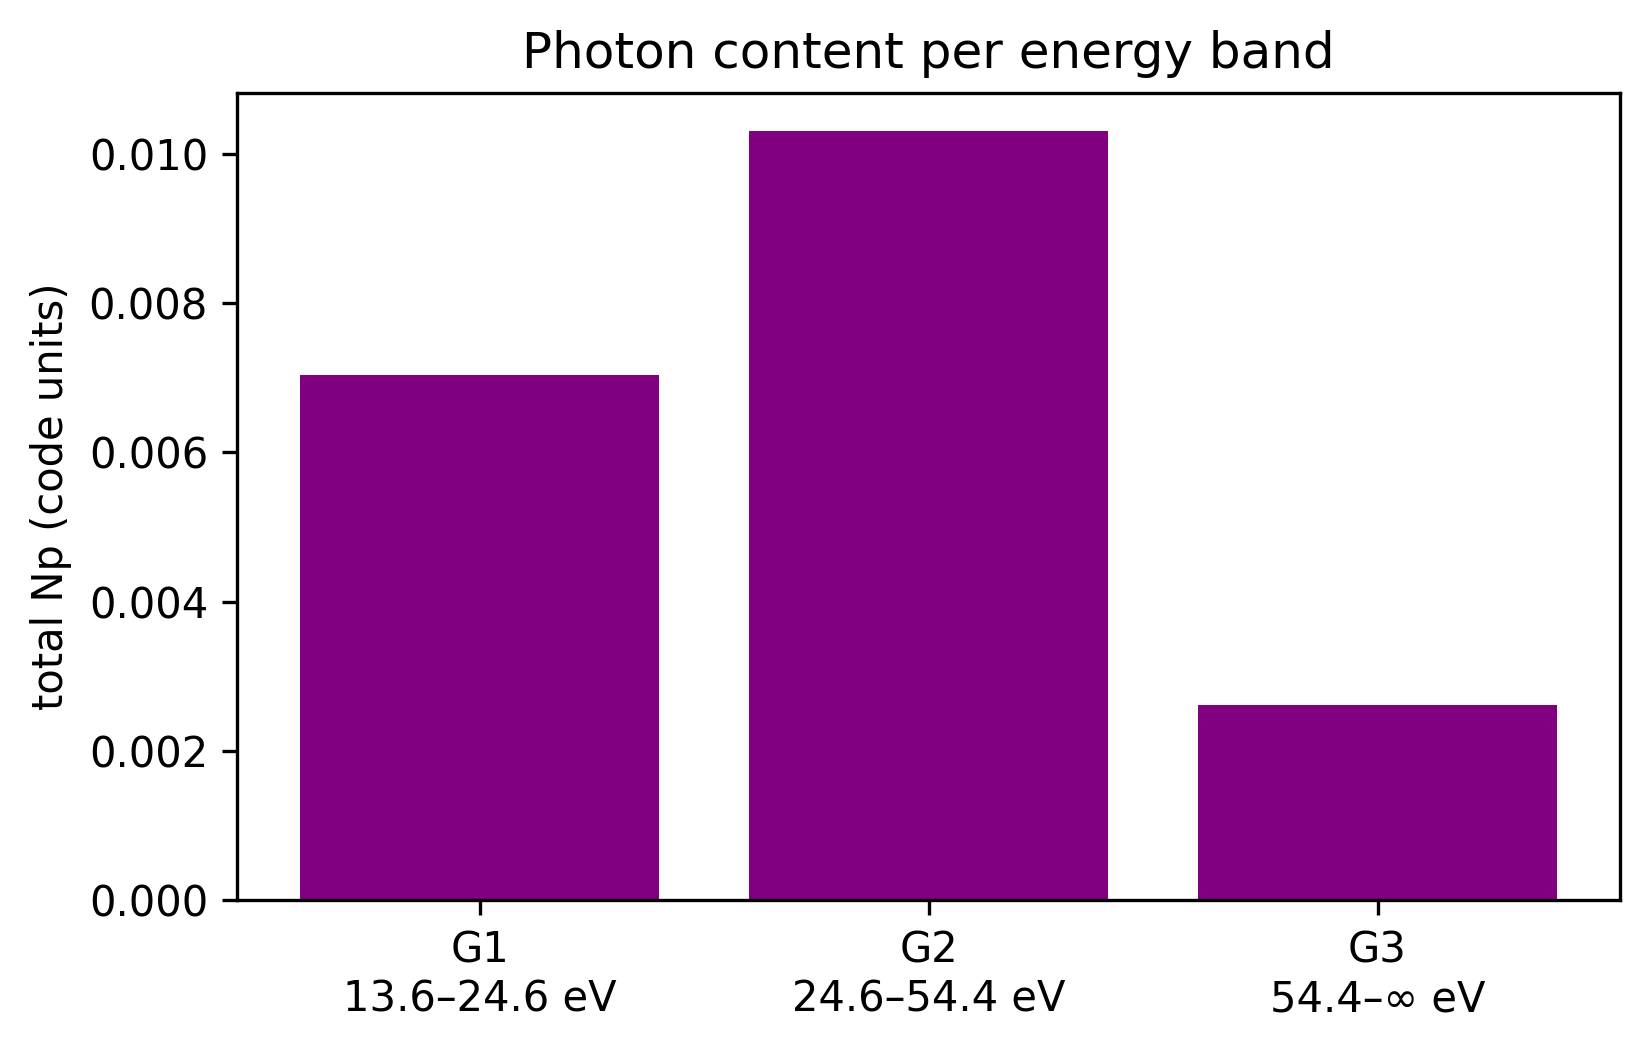

In [7]:
@show info.descriptor.rt[:group_egy]                       # mean photon energy per band [eV]
ng = info.nvarrt ÷ 4
totals = [sum(getvar(rt, Symbol("Np", g))) for g in 1:ng]
L0 = info.descriptor.rtPhotonGroups[:L0_eV]; L1 = info.descriptor.rtPhotonGroups[:L1_eV]
bands = ["G$g\n$(round(L0[g],digits=1))–$(L1[g]==0 ? "∞" : string(round(L1[g],digits=1))) eV" for g in 1:ng]
figure(figsize=(5.6,3.6)); bar(1:ng, totals, color="purple")
ylabel("total Np (code units)"); xticks(1:ng, bands)
title("Photon content per energy band"); tight_layout();

## The hydro to RT bridge

This is the conceptual pivot. The **photon transport** lives in `rt`; the **ionization state**
it produces, `xHII`, temperature, electron density, lives in the **hydro** data as passive
scalars. Load it with `gethydro`; Mera locates the ionization fractions automatically via the
RT descriptor index `iIons`, so you ask for them by name (`:xHII`, …). For this **pure-hydrogen**
run (`X=1`, `Y=0`) the free-electron density equals the HII density (`n_e = n_HII`).

In [8]:
gas = gethydro(info, verbose=false, show_progress=false)

HydroDataType(Table with 32768 rows, 11 columns:
Columns:
#   colname    type
──────────────────────
1   cx         Int64
2   cy         Int64
3   cz         Int64
4   rho        Float64
5   vx         Float64
6   vy         Float64
7   vz         Float64
8   p          Float64
9   scalar_00  Float64
10  scalar_01  Float64
11  scalar_02  Float64, InfoType(3, "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES-PUBLIC/stromgren3d", FileNamesType("/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES-PUBLIC/stromgren3d/output_00003", "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES-PUBLIC/stromgren3d/output_00003/info_00003.txt", "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES-PUBLIC/stromgren3d/output_00003/amr_00003.", "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES-PUBLIC/stromgren3d/output_00003/hydro_00003.", "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES-PUBLIC/stromgren3d/output_00003/hydro_file_descriptor.txt", "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES-PUBLI

## Ionization map: slice vs. column

`:xHII` is a hydro scalar (located via `iIons`). The source sits at the box **corner** `[0,0,0]`,
so we **zoom** on the ionized region (the Strömgren sphere is only ≈2.6 kpc in a 15 kpc box). A
**thin slice at the source plane** shows the *local* sphere with a sharp ionization front
(xHII: 0→1); the **full-column average** integrates the whole 15 kpc line of sight, mostly
neutral gas, so it is far lower and smoother (note the separate colour scale). That is the
slice-vs-column distinction: local structure vs. line-of-sight dilution.

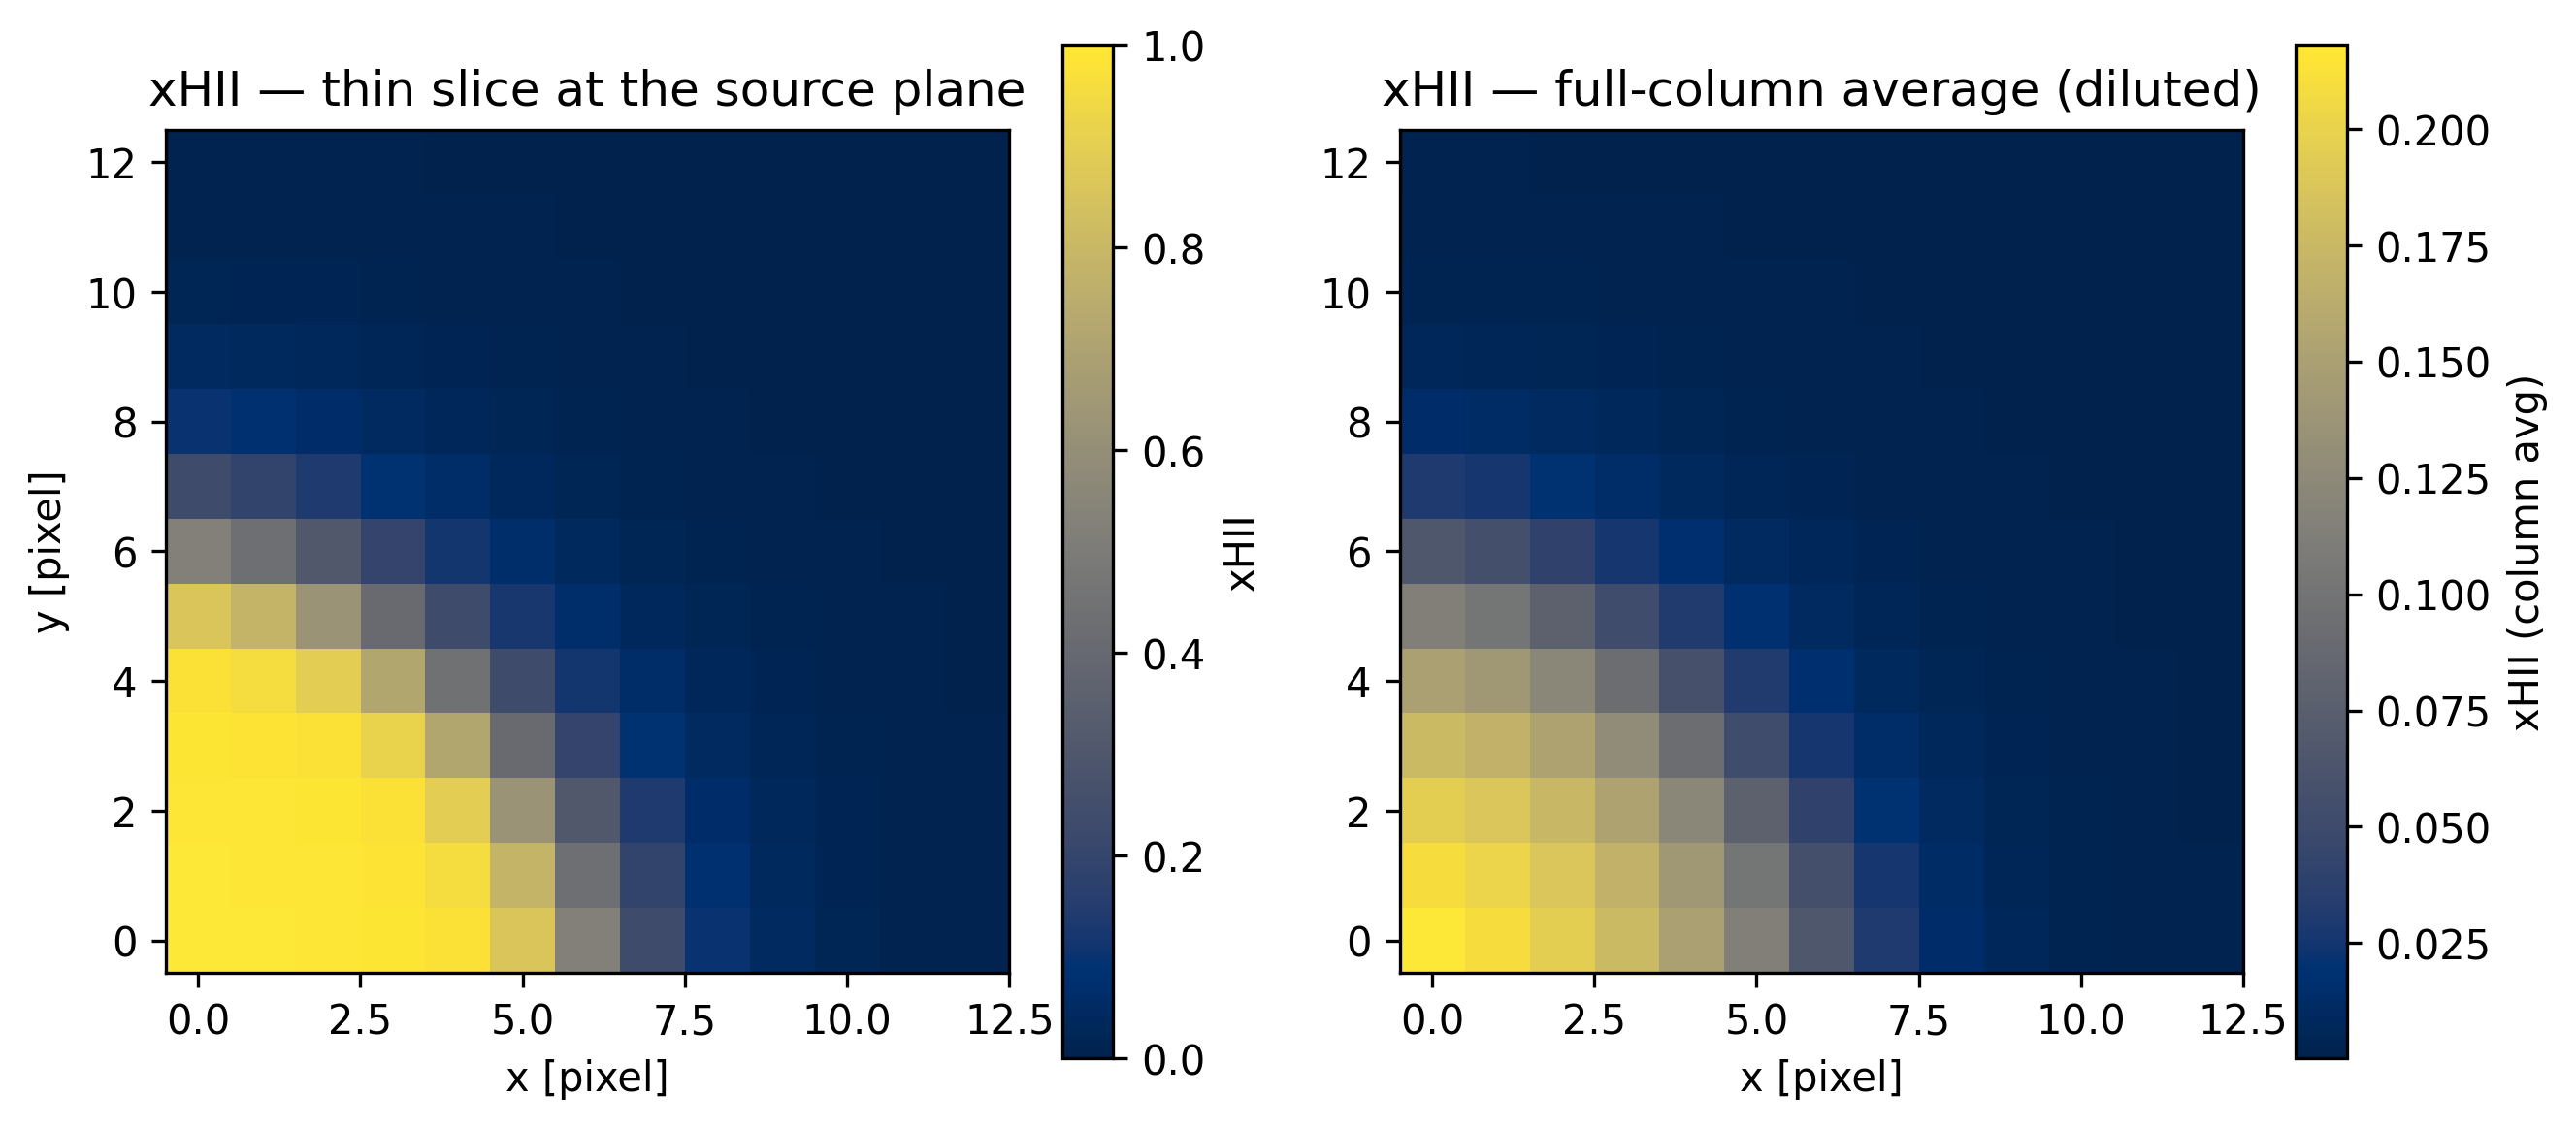

In [9]:
# source at the corner [0,0,0]; zoom on the ionized region (~2.6 kpc sphere)
slc = projection(gas, :xHII, xrange=[0,6], yrange=[0,6], zrange=[0,1],
                 center=[0.,0.,0.], range_unit=:kpc, verbose=false, show_progress=false)
col = projection(gas, :xHII, xrange=[0,6], yrange=[0,6],
                 center=[0.,0.,0.], range_unit=:kpc, verbose=false, show_progress=false)
figure(figsize=(9,4))
subplot(1,2,1); imshow(permutedims(slc.maps[:xHII]), origin="lower", cmap="cividis", vmin=0, vmax=1)
title("xHII — thin slice at the source plane"); xlabel("x [pixel]"); ylabel("y [pixel]"); colorbar(label="xHII")
subplot(1,2,2); pc = imshow(permutedims(col.maps[:xHII]), origin="lower", cmap="cividis")
title("xHII — full-column average (diluted)"); xlabel("x [pixel]"); colorbar(pc, label="xHII (column avg)"); tight_layout();

## Ionization-state number densities

From the hydrogen density and the ionization fractions, Mera derives `:n_HII`, `:n_HI` and the
free-electron density `:n_e` (all in cm⁻³). Here we use the **vector** form to fetch all three
in one call. (`n_e = n_HII` for pure H; with helium tracked, `Y>0` adds `n_HeII + 2 n_HeIII`.)

In [10]:
d = getvar(gas, [:n_HII, :n_HI, :n_e])     # → Dict of arrays
(n_HII_max = maximum(d[:n_HII]), n_HI_max = maximum(d[:n_HI]), n_e_max = maximum(d[:n_e]))

(n_HII_max = 0.0009996398159210552, n_HI_max = 0.0009999979654335613, n_e_max = 0.0009996398159210552)

## Mock recombination emission

A recombination-line image (e.g. Hα) is the line-of-sight integral of the emissivity
`j ∝ α(T)·nₑ·n_HII`. `getvar(gas, :em_recomb)` returns the proxy `n_HII²` (valid here because
the ionized gas is nearly isothermal); projecting it with `mode=:sum` gives a map proportional to
the **emission-measure column**, the synthetic glow of the HII region.

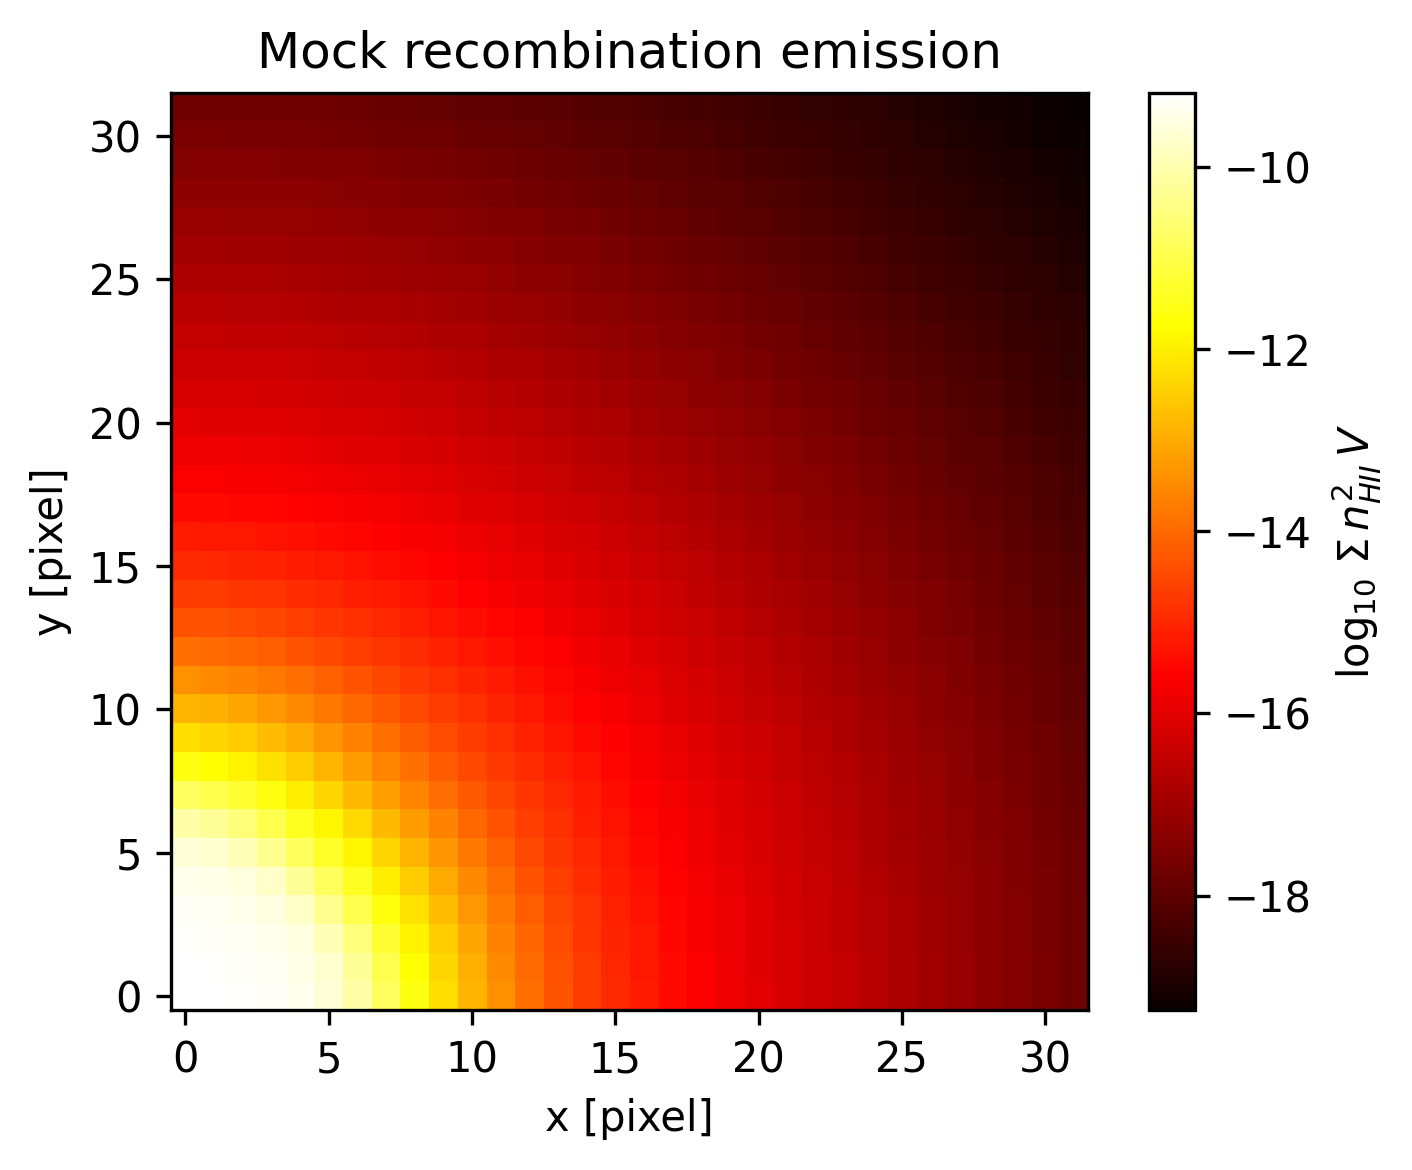

In [11]:
em = projection(gas, :em_recomb, mode=:sum, verbose=false, show_progress=false)
show_map(em.maps[:em_recomb]; logscale=true, cmap="hot",
         clabel=L"$\log_{10}\,\Sigma\,n_{HII}^2\,V$", ttl="Mock recombination emission")

## Strömgren climax: ionization & temperature profiles

The defining diagnostic, radially binned `xHII(r)` and `T_rt(r)` from the source (per-bin
mean via `radial_mean`). The **ionization front** is the radius where `xHII = 0.5`; the temperature rises to ~10⁴ K inside (peaking at ~2×10⁴ K near the hard source) and falls
outside. We compute `r`, `xHII`, `T_rt` here once and reuse them next.

round(ifront, digits = 2) = 2.61

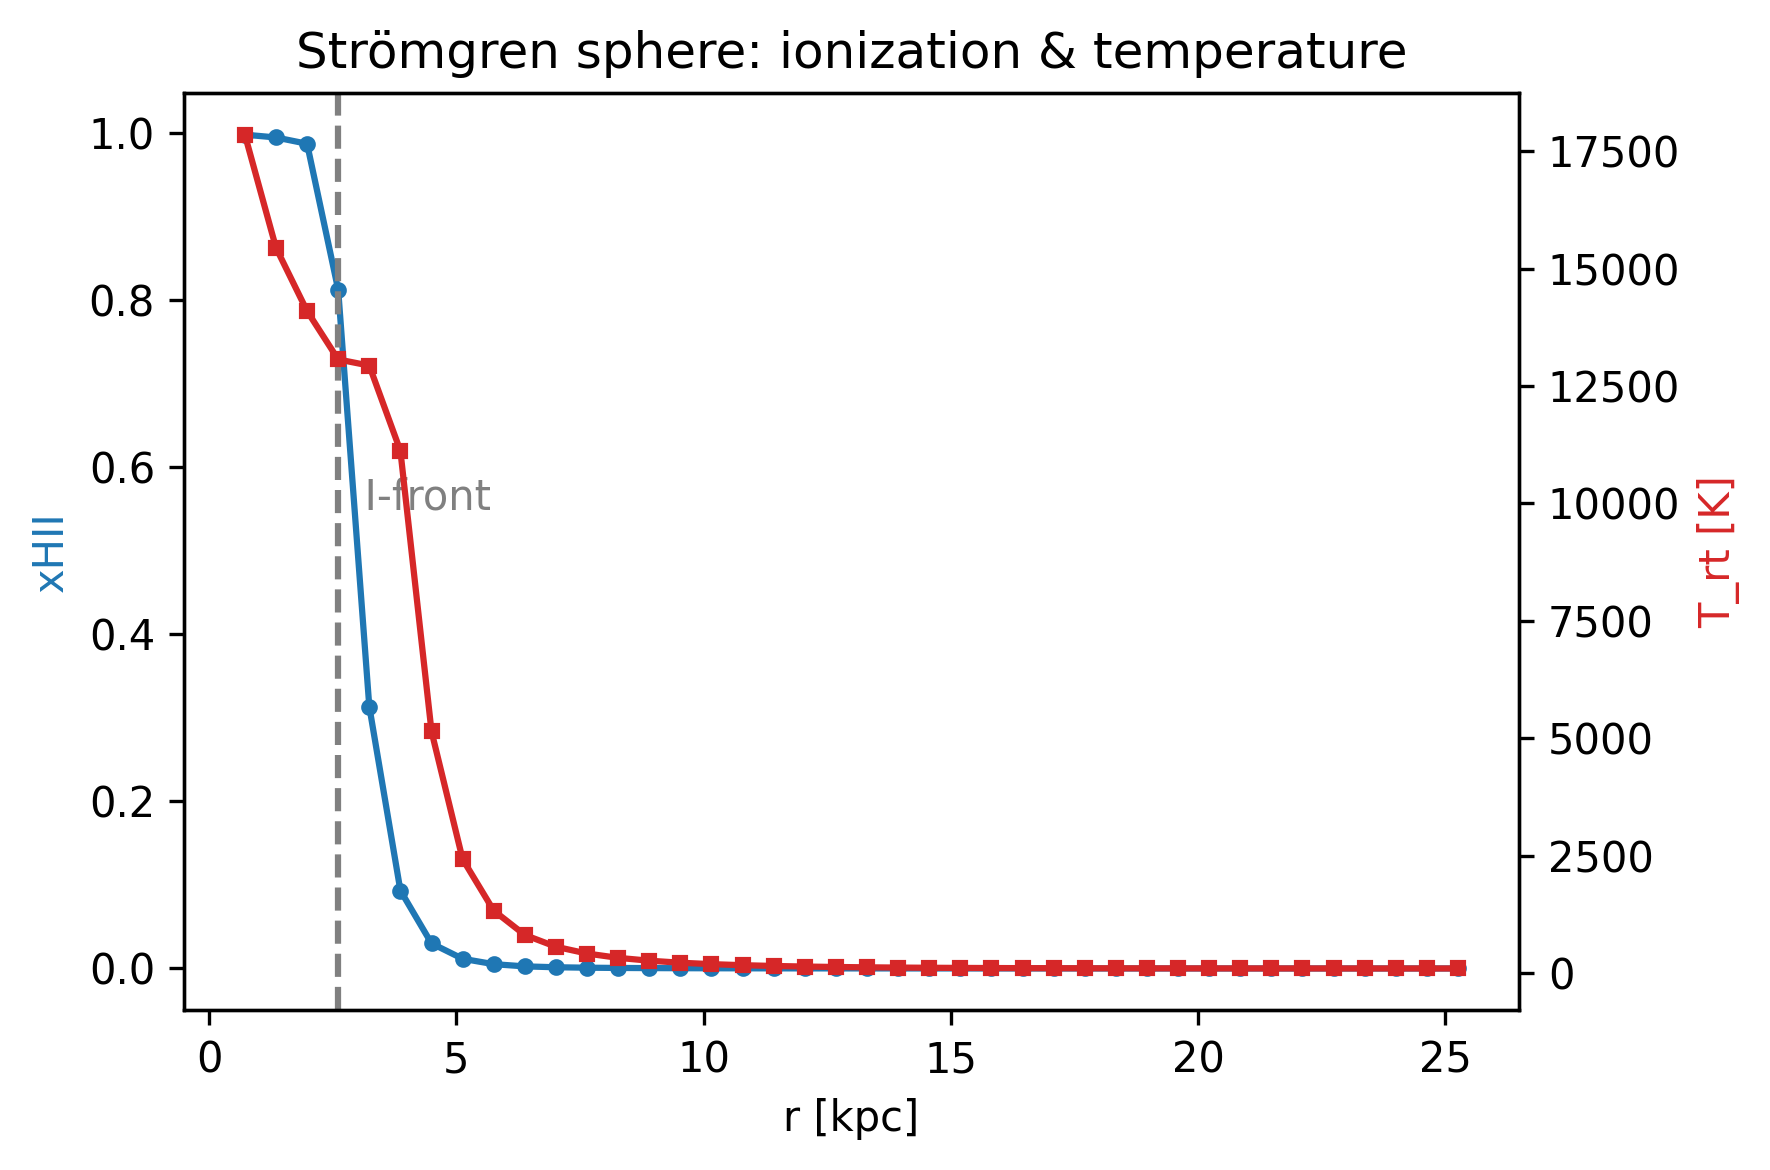

2.61

In [12]:
r_kpc = getvar(gas, :r_sphere, :kpc, center=[0.0, 0.0, 0.0])
xh    = getvar(gas, :xHII)
Trt   = getvar(gas, :T_rt)
rc1, xhm = radial_mean(r_kpc, xh)
_,   Tm  = radial_mean(r_kpc, Trt)
ifront = rc1[something(findlast(x -> !isnan(x) && x > 0.5, xhm), 1)]
fig = figure(figsize=(6,4)); ax1 = gca()
ax1.plot(rc1, xhm, "-o", color="C0", ms=3); ax1.set_xlabel("r [kpc]"); ax1.set_ylabel("xHII", color="C0")
ax1.axvline(ifront, ls="--", color="gray"); ax1.text(ifront, 0.55, "  I-front", color="gray")
ax2 = ax1.twinx(); ax2.plot(rc1, Tm, "-s", color="C3", ms=3); ax2.set_ylabel("T_rt [K]", color="C3")
title("Strömgren sphere: ionization & temperature"); tight_layout();
@show round(ifront, digits=2)   # measured ionization-front radius [kpc]

## Mean molecular weight μ and the temperature

The temperature follows `T ∝ μ` at fixed `P/ρ`, so the **mean molecular weight** matters. μ
depends on the ionization state: for pure H, `μ = 1/(1+xHII)`, running from **1.0** (neutral,
since `X=1` here) to **0.5** (fully ionized). Mera's plain `:T` (`unit=:K`) bakes in a *constant*
μ ≈ 1/0.76 ≈ 1.32 (the fixed primordial default, **independent of this run's `X=1`**), so it
**over-estimates** the ionized-gas temperature by `μ_const/μ_local` ≈ 1.32/0.5 ≈ **2.6×** (matching
the printed `T_const/T_rt`); **`:T_rt`** uses the *local* μ and recovers the physical temperature
(~2×10⁴ K here). (μ also responds to metallicity via the `:metallicity` scalar when present; this
test is metal-free.)

Because the medium is uniform and in photoionization equilibrium, `T` is single-valued in `xHII`
the cells trace a **1D relation**, so a scatter (coloured by radius) is the honest plot; a 2D
density to temperature phase *heatmap* would collapse to a line here and only becomes informative in
a multiphase ISM/galaxy run.

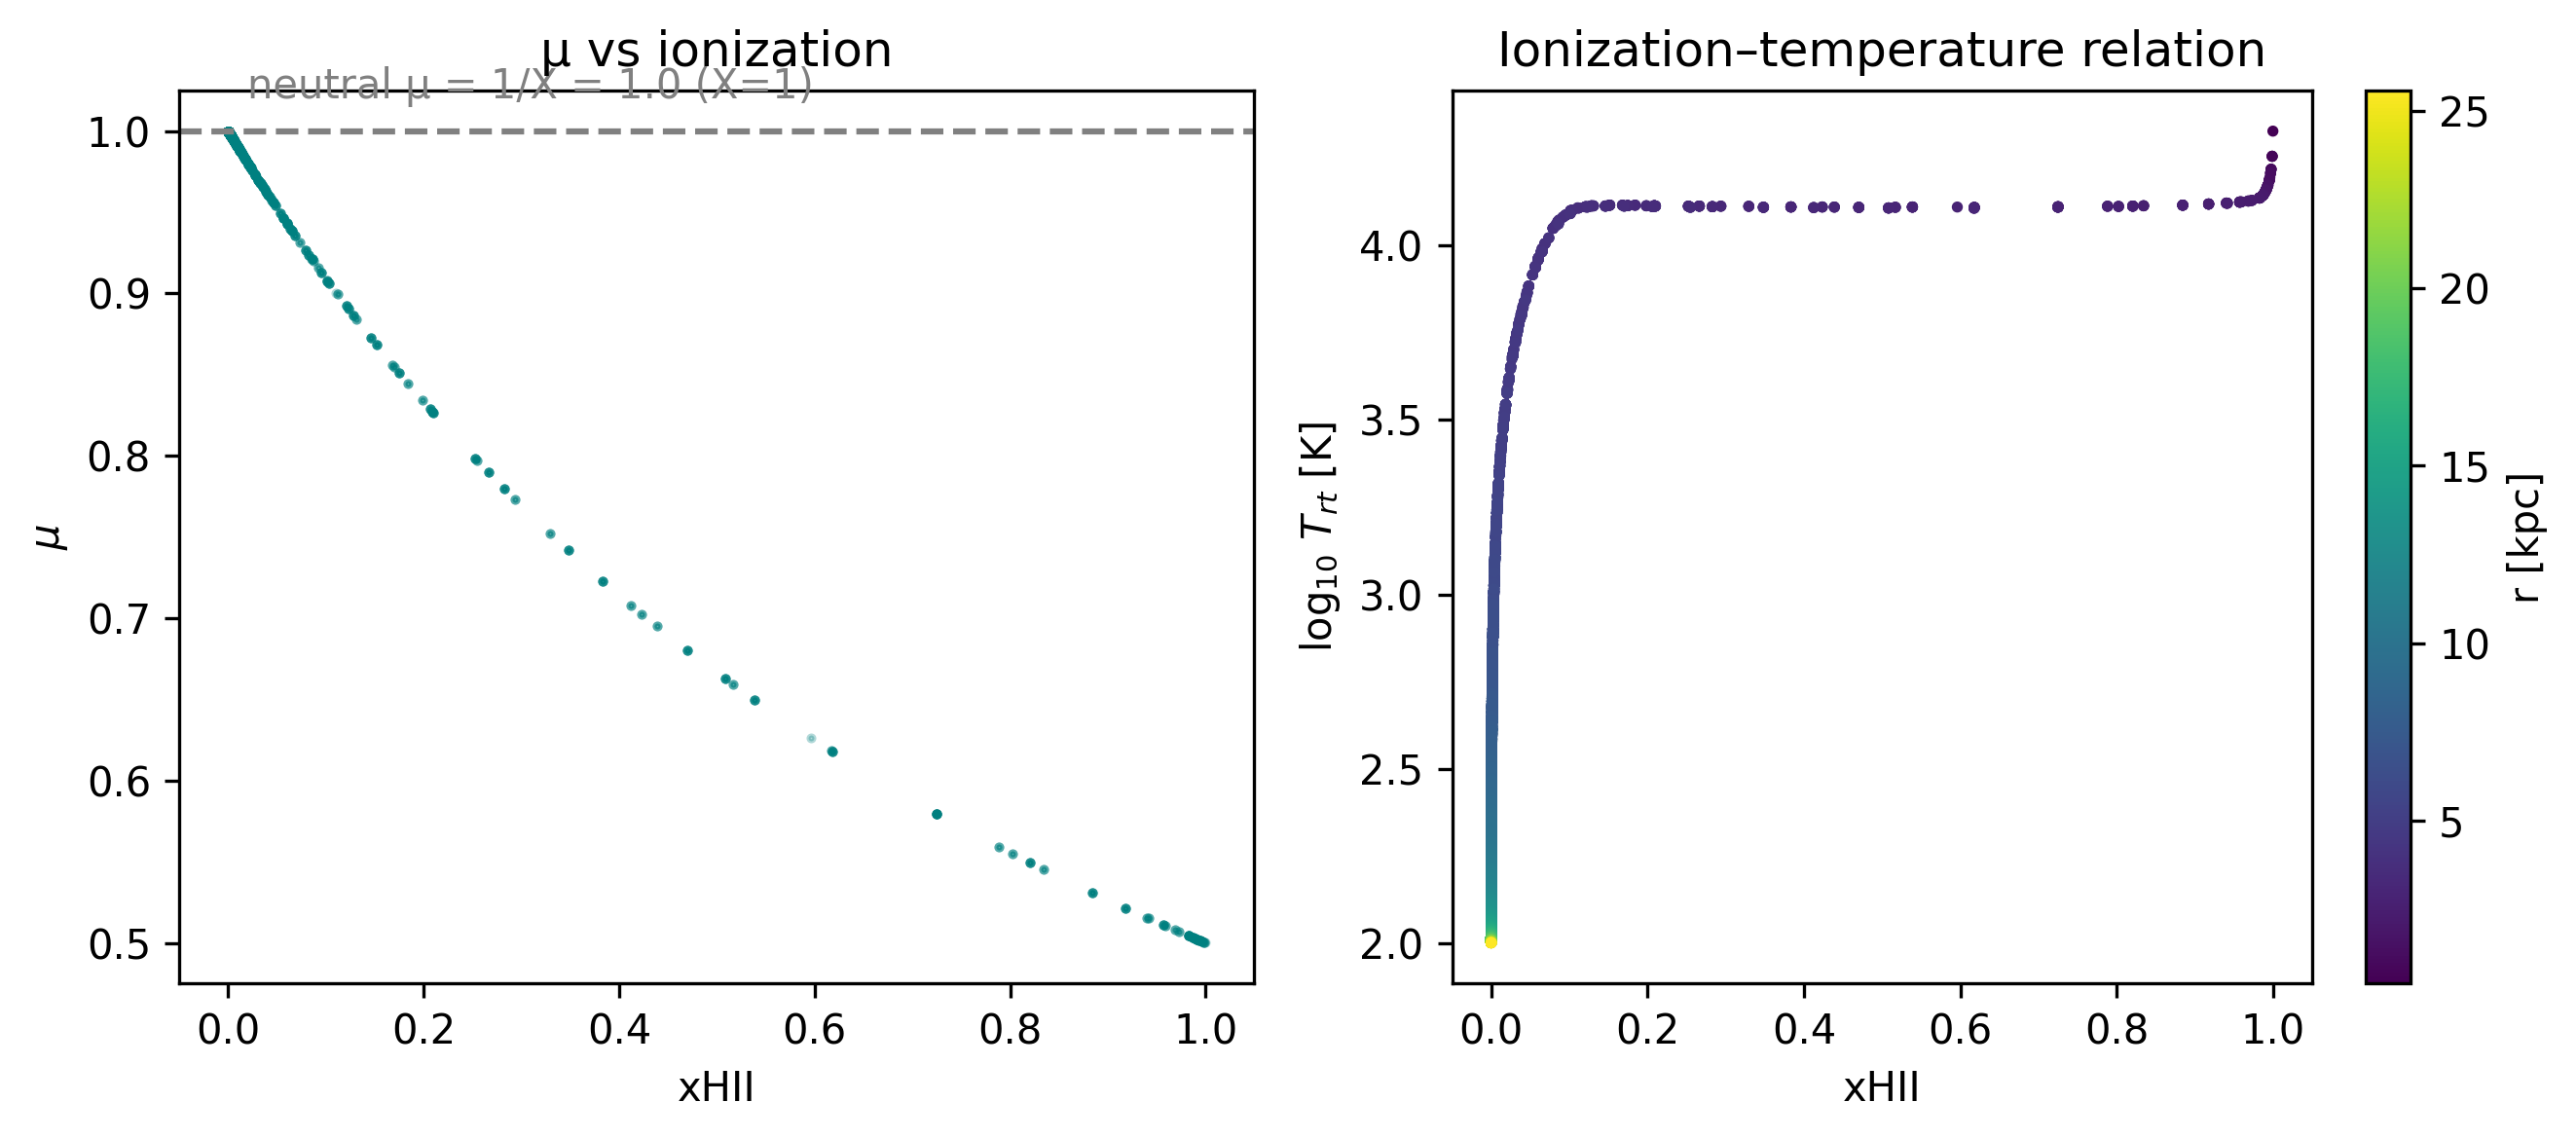

(T_const_max = 55977.75489365413, T_rt_max = 21275.378385872624)

In [13]:
q = getvar(gas, [:mu, :T, :T_rt], [:standard, :K, :K])    # vector vars + per-var units
figure(figsize=(9,4))
subplot(1,2,1); scatter(xh, q[:mu], s=2, alpha=0.3, color="teal")
axhline(1.0, ls="--", color="gray"); text(0.02, 1.02, "neutral μ = 1/X = 1.0 (X=1)", color="gray")
xlabel("xHII"); ylabel(L"\mu"); title("μ vs ionization")
subplot(1,2,2); sc = scatter(xh, log10.(q[:T_rt]), c=r_kpc, s=3, cmap="viridis")
colorbar(sc, label="r [kpc]"); xlabel("xHII"); ylabel(L"$\log_{10}\,T_{rt}$ [K]")
title("Ionization–temperature relation"); tight_layout();
(T_const_max = maximum(q[:T]), T_rt_max = maximum(q[:T_rt]))

## Radiation to matter rates & ionization balance

The radiation field drives the gas. From the **RT** object: the **photoionization rate**
`Γ_HI = Σ_g c·Np_g·σ_g` [s⁻¹] (using the reduced light speed `rt_c_frac·c`) and the
**photoheating rate** per HI atom. From the **hydro** object: the **recombination rate**
`α_B(T)·n_e·n_HII`. In photoionization equilibrium these balance *locally*:
`Γ·n_HI ≈ α·n_e·n_HII`.

Quantities that **couple both objects** (`:photoionizations`, `:ionization_balance`) are
requested on the RT object with `hydro_data=gas` (both loaded over the same cells, Mera
checks the alignment). The radial profile below shows the two rates **tracking in shape**
through the ionized interior. They are **not yet equal**: at this early time
`t ≈ 20 Myr ≪ t_rec ≈ 120 Myr` (`t/t_rec ≈ 0.16`) the front is still **expanding** toward `R_S`,
so photoionizations currently outpace recombinations (core ratio ≈ 5 > 1). Exact local balance
(ratio → 1) is reached only asymptotically (`t ≫ t_rec`).

maximum(getvar(rt, :Gamma_HI)) = 1.1379022132736983e-12
maximum(getvar(rt, :photoheating_HI)) = 1.357061014902275e-23
round(sum(pion[core]) / sum(rec[core]), digits = 2) = 4.2


maximum(getvar(rt, :ionization_balance, hydro_data = gas)) = 3.2746012509460365e-18


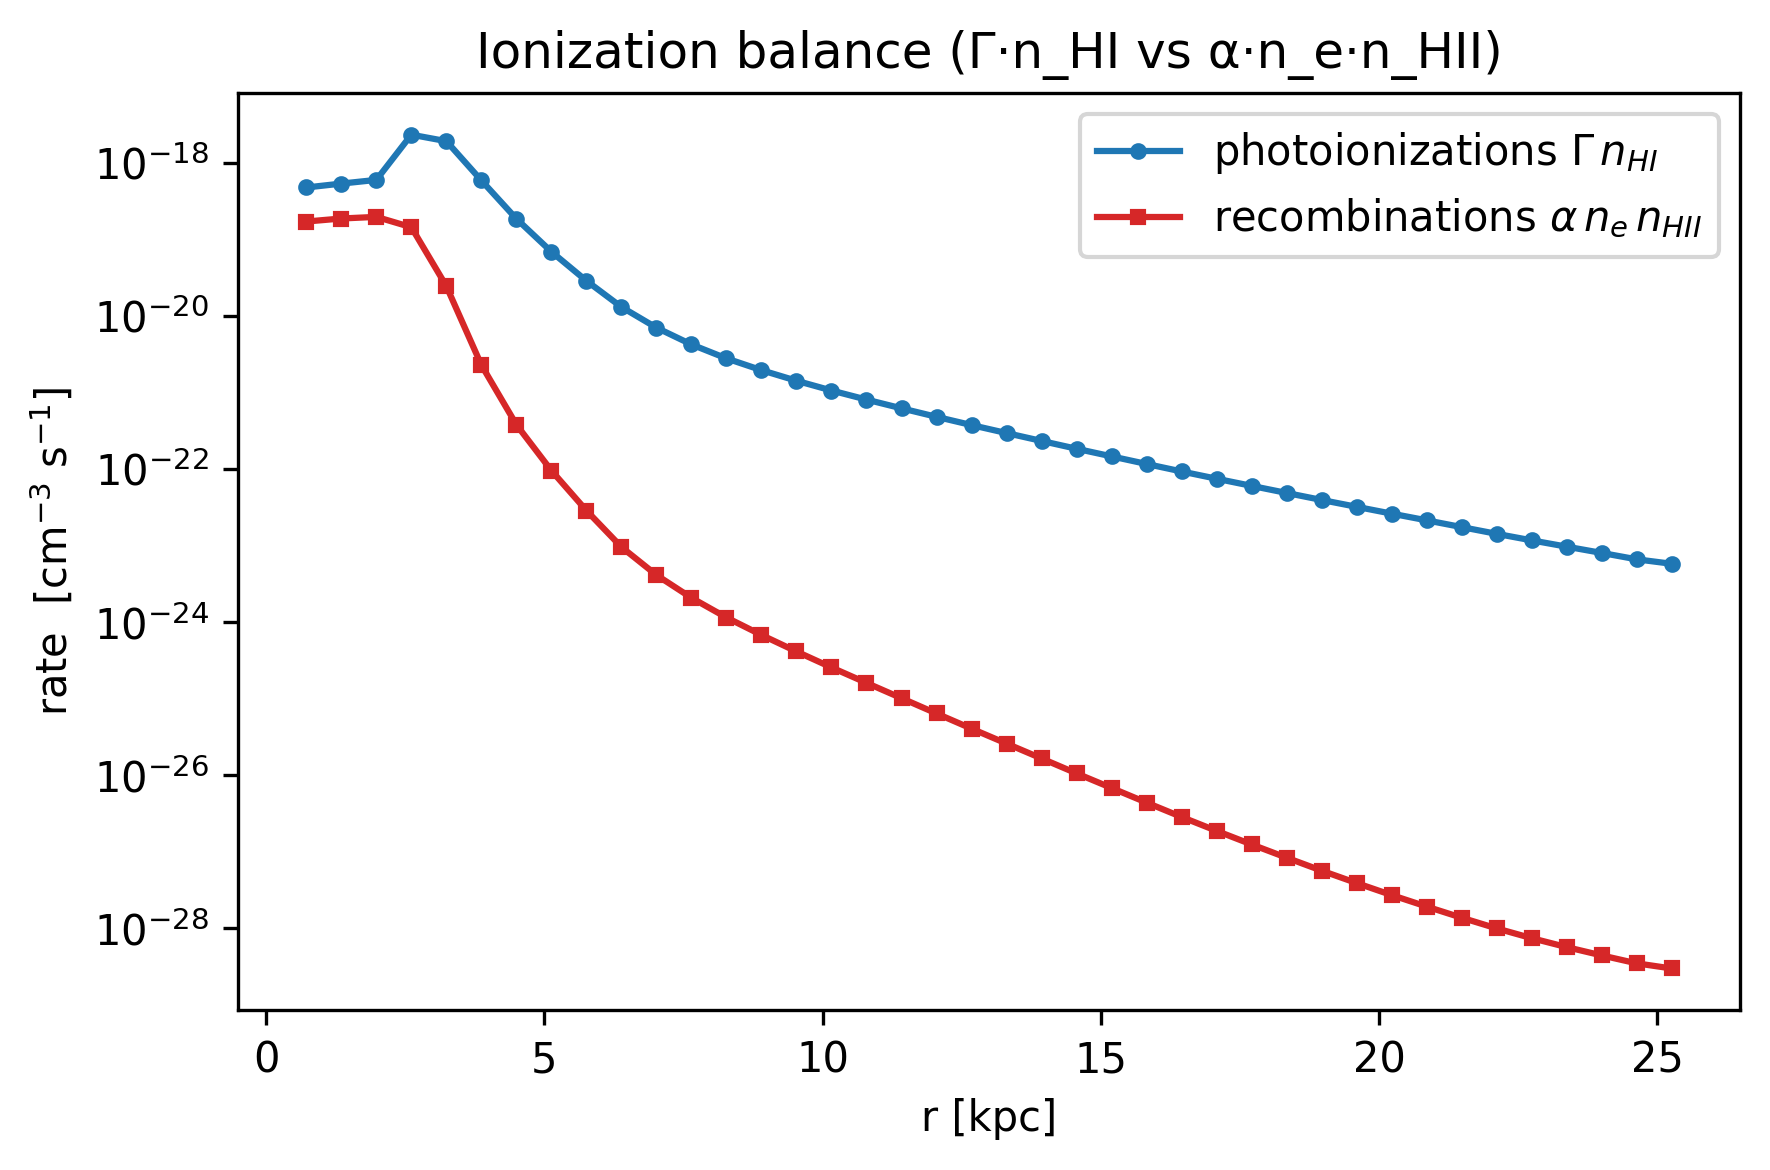

In [14]:
@show maximum(getvar(rt, :Gamma_HI))          # photoionization rate [1/s]
@show maximum(getvar(rt, :photoheating_HI))   # photoheating per HI atom [erg/s]

# photoionizations (Γ·n_HI, couples rt+gas) vs recombinations (α_B(T)·n_e·n_HII, gas)
pion = getvar(rt, :photoionizations, hydro_data=gas)
rec  = getvar(gas, :recomb_rate)
rcb, pion_r = radial_mean(r_kpc, pion)
_,   rec_r  = radial_mean(r_kpc, rec)
core = getvar(gas, :xHII) .> 0.9
@show round(sum(pion[core]) / sum(rec[core]), digits=2)   # >1 ⇒ still ionizing (t ≪ t_rec); → 1 only as t ≫ t_rec
@show maximum(getvar(rt, :ionization_balance, hydro_data=gas))   # Γ·n_HI − α·n_e·n_HII

figure(figsize=(6,4))
semilogy(rcb, pion_r, "-o", ms=3, color="C0", label=L"photoionizations $\Gamma\,n_{HI}$")
semilogy(rcb, rec_r,  "-s", ms=3, color="C3", label=L"recombinations $\alpha\,n_e\,n_{HII}$")
xlabel("r [kpc]"); ylabel(L"rate  [cm$^{-3}$ s$^{-1}$]")
legend(loc="upper right"); title("Ionization balance (Γ·n_HI vs α·n_e·n_HII)"); tight_layout();

## Physical units & the descriptor

`getinfo` parsed the RT descriptor (`info_rt`) into `info.descriptor.rt`: the unit factors
`unit_np`/`unit_pf`, the per-group `group_egy`, and `rtPhotonGroups` (cross-sections, band edges).
Two ways to physical units: **dedicated cgs symbols** (`:Np1_cgs`, `:Fmag1_cgs`,
`:rad_energy_density`, these return fixed cgs and ignore a unit argument), and the general
`getvar(obj, :var, :unit)` route for plain quantities (as we used for radius in kpc). We lead with
the radiation energy density `u = Np·unit_np·egy`, it carries the eV factor and is genuinely
`~10⁻¹³ erg cm⁻³`. (Here `Np1_cgs` happens to equal the code value only because `unit_np≈1` in
this run.)

info.descriptor.rt[:group_egy] = [18.85, 35.08, 65.67]
info.descriptor.rtPhotonGroups[1] = Dict{Symbol, Any}(:cse_cm2 => [2.78e-18, 0.0, 0.0], :egy_eV => 18.85, :csn_cm2 => [3.0e-18, 0.0, 0.0])
maximum(getvar(rt, :rad_energy_density)) = 1.1090467888595723e-13
extrema(getvar(rt, :Np1_cgs)) = (1.9695717303063266e-49, 0.0010425690408447943)


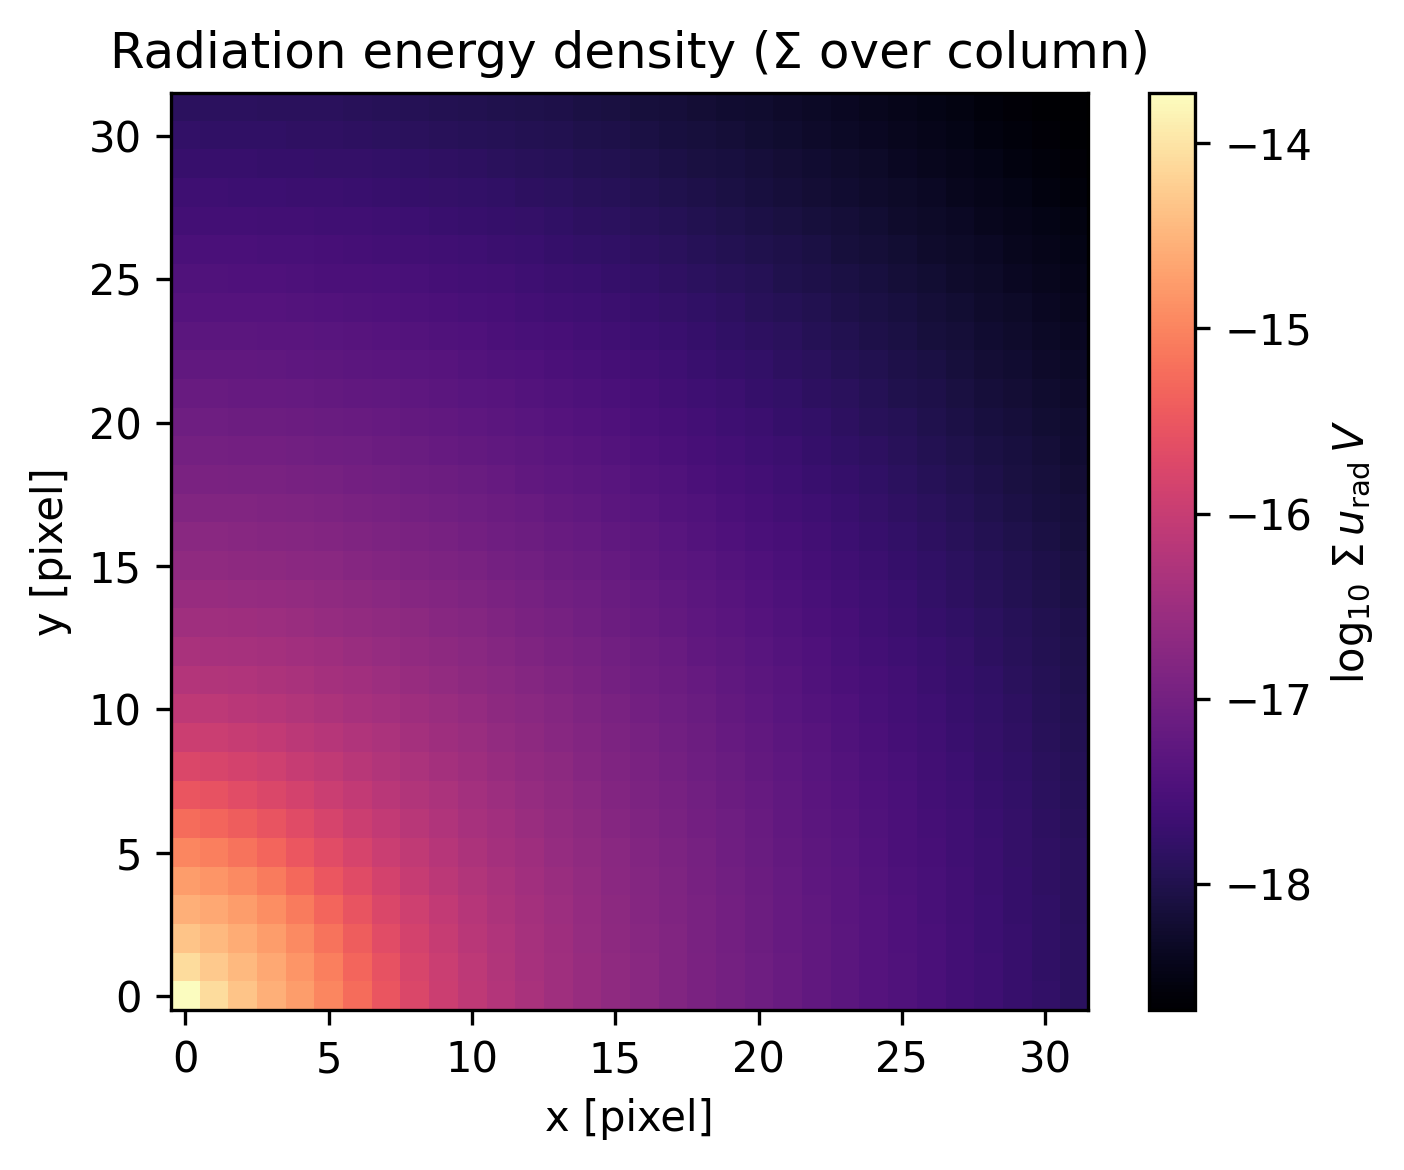

In [15]:
@show info.descriptor.rt[:group_egy]
@show info.descriptor.rtPhotonGroups[1]                 # band 1: egy_eV, csn_cm2, cse_cm2
@show maximum(getvar(rt, :rad_energy_density))          # [erg cm^-3]
@show extrema(getvar(rt, :Np1_cgs))                     # = code value here only (unit_np≈1)
um = projection(rt, :rad_energy_density, mode=:sum, verbose=false, show_progress=false)
show_map(um.maps[:rad_energy_density]; logscale=true, cmap="magma",
         clabel=L"$\log_{10}\,\Sigma\,u_{\rm rad}\,V$", ttl="Radiation energy density (Σ over column)")

## Further quantities & a quantitative Strömgren check

Other RT quantities are one call each (per-group reduced flux, physical flux, per-group energy
density, neutral fraction `:xHI`). Finally we close the loop on the **physics we expected**: compute the **Strömgren
radius** from the source rate and compare to the measured front. `Ṅγ` is a hand-entered namelist
constant (not in the cell data); `α_B` is the case-B coefficient at ~10⁴ K; `n_H` comes from the
data. At this early time `t ≪ t_rec`, so the front is still **expanding** toward `R_S`,
the right comparison is the time-dependent `r_I(t) = R_S(1-e^{-t/t_rec})^{1/3}`.

In [16]:
@show maximum(getvar(rt, :reducedflux1))
@show maximum(getvar(rt, :Fmag1_cgs))
@show maximum(getvar(rt, :photon_energy_density1))
@show extrema(getvar(gas, :xHI))

Ndot = 5.0e48; alpha_B = 2.59e-13; kpc = 3.085677e21          # Ṅγ from stromgren.nml; case-B α_B
nH   = mean(getvar(gas, :n_HII) .+ getvar(gas, :n_HI))        # total H [cm^-3]
R_S  = (3Ndot / (4π * alpha_B * nH^2))^(1/3) / kpc            # asymptotic Strömgren radius [kpc]
t    = info.time * info.scale.s; t_rec = 1 / (alpha_B * nH)
r_I  = R_S * (1 - exp(-t / t_rec))^(1/3)                      # time-dependent I-front [kpc]
println("n_H              = ", round(nH, sigdigits=3), " cm^-3")
println("R_S (asymptotic) = ", round(R_S, digits=2), " kpc")
println("r_I(t=", round(info.time*info.scale.Myr, digits=0), " Myr) = ", round(r_I, digits=2),
        " kpc   (t_rec = ", round(t_rec/3.156e13, digits=0), " Myr)")
println("measured front   = ", round(ifront, digits=2), " kpc   → still expanding toward R_S")

maximum(getvar(rt, :reducedflux1)) = 0.9888163855508687
maximum(getvar(rt, :Fmag1_cgs)) = 13086.144286562321
maximum(getvar(rt, :photon_energy_density1)) = 3.14866584114071e-14
extrema(getvar(gas, :xHI)) = (0.00036018407894478077, 0.9999979654335612)
n_H              = 0.001 cm^-3
R_S (asymptotic) = 5.39 kpc
r_I(t=30.0 Myr) = 3.24 kpc   (t_rec = 122.0 Myr)
measured front   = 2.61 kpc   → still expanding toward R_S


## Summary, RT calls at a glance

| call | result |
|---|---|
| `getinfo(output, path)` | read the snapshot header + RT descriptor → `InfoType` |
| `getrt(info)` | load RT leaf-cells → `RtDataType` |
| `getvar(rt, :Np1)` / `[:Np1,:Fx1,:Fy1]` | one / several photon fields |
| `getvar(rt, :Fmag1)`, `:Np_total`, `:reducedflux1` | flux magnitude, total density, reduced flux |
| `getvar(rt, :r_sphere, :kpc, center=…)` | geometry + unit conversion |
| `subregion` / `shellregion` | spatial selection on RT |
| `projection(rt, var; mode=:standard/:sum)` | 2D average / sum map (volume-weighted) |
| `info.descriptor.rt[:group_egy]`, `rtPhotonGroups` | photon-group / energy-band properties |
| `gethydro(info)` → `:xHII`, `:xHI` | ionization state (via `iIons`) |
| `getvar(gas, [:n_HII,:n_HI,:n_e])` | ionization-state densities [cm⁻³] |
| `getvar(rt, :Gamma_HI)`, `:photoheating_HI` | photoionization / photoheating rate |
| `getvar(gas, :recomb_rate)` | case-B recombination rate [cm⁻³ s⁻¹] |
| `getvar(rt, :ionization_balance, hydro_data=gas)` | radiation to gas coupling (Γ·n_HI − α·nₑ·n_HII) |
| `getvar(gas, :em_recomb)` | recombination-emission proxy `n_HII²` |
| `getvar(gas, [:mu,:T,:T_rt],[…])` | μ and RT-aware temperature [K] |
| `getvar(rt, :Np1_cgs)`, `:rad_energy_density` | physical (cgs) photon density / energy density |
| Strömgren check: `R_S`, `r_I(t)` vs measured I-front | quantitative validation (closes the opening prediction) |

Photon transport (`rt`) and ionization state (`gas`) are separate objects bridged by `iIons`;
everything runs through the one `getvar` / `projection` pipeline.